# Along-track correction vs. the uncorrected fallback

`lunaserv.hapke_shade_ortho`'s per-pixel photometric angles come from one **frozen** camera
position (`Camera.camera_center_moon_me_m`, matched to the crop's own center-frame time) -- but
the WAC crop is a ~97s pushframe scan, during which the spacecraft moved ~150km (confirmed via
ISIS `campt`'s `SpacecraftPosition` at the crop's edges). So the raw per-pixel view direction is
only accurate near the crop's own center; it's a mismatched, wrong-epoch position everywhere else.

`lunaserv._terrain_photometric_angles`'s `along_track_correction` is a "poor man's" fix for this
that doesn't need per-line timing: project the raw view direction onto the plane perpendicular to a
chosen along-track vector before computing emission/phase -- i.e. trust only the *cross-track*
component of the raw (wrong-position) view direction, discarding its along-track component
entirely, on the assumption that a scanning pushframe sensor observes each line close to nadir
*in its own along-track direction* at the instant it's captured. **On by default**
(`DEFAULT_ALONG_TRACK_CORRECTION`) -- this notebook is now a reference/regression comparison
against the uncorrected fallback (`along_track_correction=False`), not an "should we turn this on"
evaluation anymore.

The "along-track" vector used below is `Camera.camera_along_track_direction_moon_me` -- the
camera's own re-aimed attitude's pre-twist X axis (`camera.py`'s "Boresight re-aiming": the
sensor-model axis convention comment there identifies this as along-track/py; the *other*
pre-twist axis, cross(z, x), is cross-track/px, not this) -- rather than the spacecraft's raw
orbital velocity. Getting the specific axis right matters: validated against ISIS `campt` phase at
5 points for this crop, the wrong (cross-track) axis is worse than no correction at all, while the
camera-attitude axis clearly beats the generic orbital-velocity one.

Minimum setup: same Phase-1-2-only pattern as `hapke_hillshade.ipynb` (no `sat_sim` render needed),
plus the WAC crop (`entry.crop_result`) `image_generation.ipynb` already generates, reprojected
once via ISIS's own `cam2map` -- the ground-truth comparison target.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rioxarray
import xarray

import trntest
from trntest import isis_wac, lunaserv

images = trntest.read_manifest("dataset_manifest.csv")
session = trntest.Session()

dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
entry = dataset[0]
camera = entry.camera

print(f"EDR product: {entry.edr_product}")

EDR product: M1327210646CE


## Reproject the real WAC crop once

The cam2map reprojection grid (bbox/CRS) comes from the DEM/ortho fetch, not from which shading
mode produced the ortho's own pixel values -- so this reprojection is identical regardless of
`along_track_correction`, and only needs doing once for both comparisons below.

In [2]:
mapproj_cub = entry.crop_result.cub_path.with_name(entry.crop_result.cub_path.stem + "-cam2map.cub")
mapproj_tif = entry.crop_result.cub_path.with_name(entry.crop_result.cub_path.stem + "-cam2map.tif")
mapproj_cub.unlink(missing_ok=True)
mapproj_tif.unlink(missing_ok=True)
mapprojected_crop_path = isis_wac.run_cam2map_for_crop(
    entry.crop_result, entry.dem_ortho_result, entry.per_image_config
)

real_crop_da = rioxarray.open_rasterio(mapprojected_crop_path, masked=True)
assert isinstance(real_crop_da, xarray.DataArray)
real_crop_da = real_crop_da.squeeze()
real_crop_display = real_crop_da.values.astype(np.float64)

## Render both basemap variants and diff each against the real crop

`along_track_correction=True`/`False` each write to their own filename (`ortho_shaded_filename`),
so both can be fetched here without disturbing whichever one `entry.dem_ortho_result`/
`image_generation.ipynb` later resumes from -- no cleanup fetch needed.

In [3]:
def basemap_and_diff(along_track_correction: bool):
    dem_ortho = lunaserv.fetch_dem_and_ortho(
        camera, entry.per_image_config, hapke=True, along_track_correction=along_track_correction
    )
    basemap_da = rioxarray.open_rasterio(dem_ortho.ortho, masked=True)
    assert isinstance(basemap_da, xarray.DataArray)
    basemap_da = basemap_da.squeeze()
    # Independently-fetched/reprojected rasters don't necessarily land on identical pixel grids --
    # align by real coordinate rather than assuming matching array shapes. Linear interpolation
    # (not compute_brightness_matched_diff's nearest+tolerance) since the two grids' pixel pitch
    # drifts by a fraction of a cell across the image -- nearest-neighbor's hard tolerance cutoff
    # leaves a gap row right where that drift crosses the tolerance boundary.
    basemap_aligned = basemap_da.interp_like(real_crop_da, method="linear")
    basemap_crop = basemap_aligned.values.astype(np.float64)
    scale = np.nanmedian(basemap_crop) / np.nanmedian(real_crop_display)
    diff = basemap_crop - real_crop_display * scale
    return basemap_crop, diff


basemap_corrected, diff_corrected = basemap_and_diff(along_track_correction=True)
basemap_uncorrected, diff_uncorrected = basemap_and_diff(along_track_correction=False)

ROI center (lon,lat deg): (np.float64(169.57486295387), np.float64(38.762076131300994)), bbox (local m): (-108890.25396707715, -111272.06778516257, 116875.28268071412, 115462.19072343325)
ROI size 2258x2267 px (~100.0 m/px)


WAC_EMP tile: WAC_EMP_643NM_E300N1350_304P


ROI center (lon,lat deg): (np.float64(169.57486295387), np.float64(38.762076131300994)), bbox (local m): (-108890.25396707715, -111272.06778516257, 116875.28268071412, 115462.19072343325)
ROI size 2258x2267 px (~100.0 m/px)


WAC_EMP tile: WAC_EMP_643NM_E300N1350_304P


## Comparison

Top row: today's default (`along_track_correction=True`). Bottom row: the uncorrected fallback.
Each right-hand panel is `basemap - real` (brightness-matched at the median) -- a strong,
direction-consistent color there means the basemap's predicted shading pattern doesn't match the
real data's; less color / more uniform noise means a better match. `mean|diff|` in each title is
the same brightness-matched-difference metric `plotting.compute_brightness_matched_diff` provides
as a reusable function.

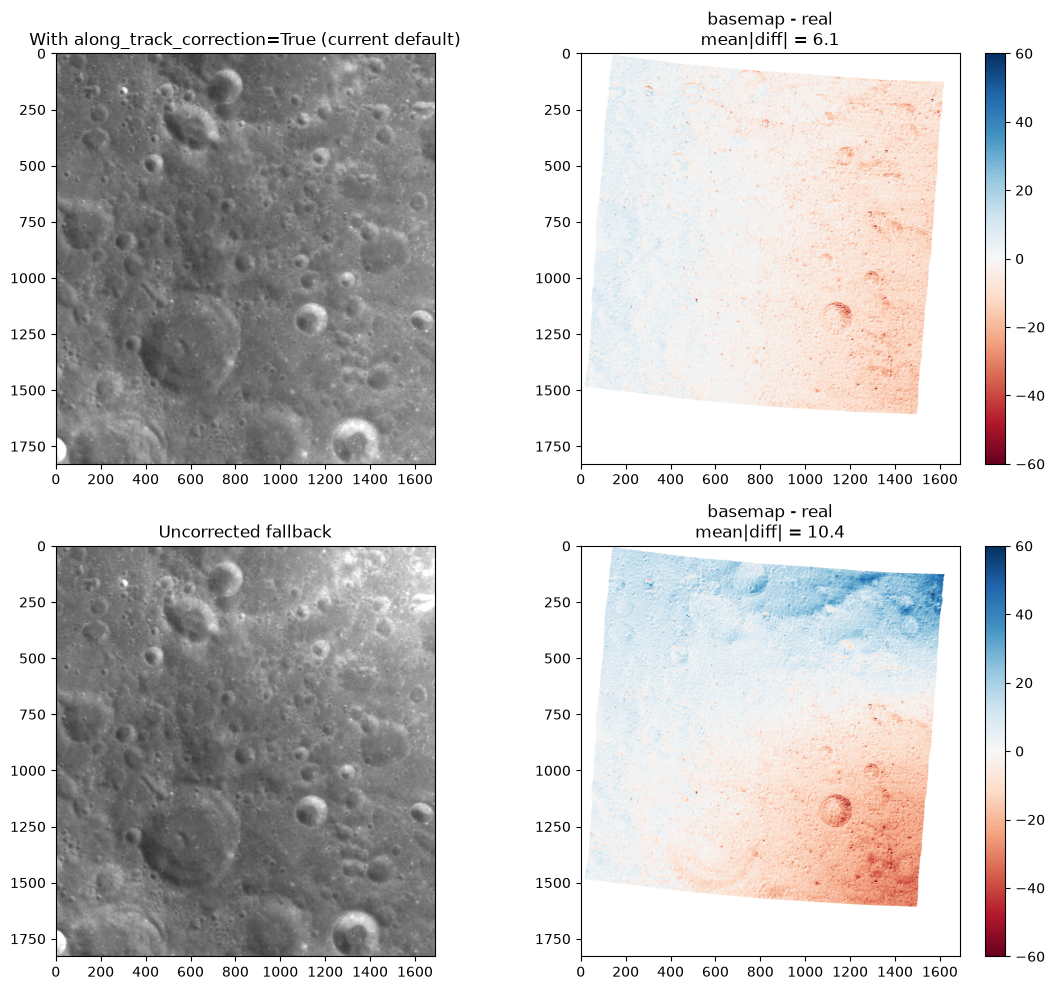

In [4]:
vmax = np.nanpercentile(basemap_corrected, 99.9)
rows = [
    ("With along_track_correction=True (current default)", basemap_corrected, diff_corrected),
    ("Uncorrected fallback", basemap_uncorrected, diff_uncorrected),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for row, (title, basemap, diff) in enumerate(rows):
    axes[row, 0].imshow(basemap, cmap="gray", vmin=0, vmax=vmax)
    axes[row, 0].set_title(title)
    im = axes[row, 1].imshow(diff, cmap="RdBu", vmin=-60, vmax=60)
    axes[row, 1].set_title(f"basemap - real\nmean|diff| = {np.nanmean(np.abs(diff)):.1f}")
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046)
plt.tight_layout()